# 04D - Explicabilidad SHAP para XGBoost V2

Este notebook deja implementada la explicabilidad del modelo final del proyecto.

- Modelo oficial: `XGBoost`.
- Variable objetivo: `susceptibility`.
- Clases: `Susceptible` y `Resistant`.
- Salida esperada: probabilidad de susceptibilidad, probabilidad de resistencia y factores SHAP por predicción.

No se entrenan modelos nuevos ni se hace búsqueda de hiperparámetros. Se usa la configuración destacada de XGBoost ya seleccionada en V2.

## 1. Librerías y rutas

Ejecutar este notebook desde JupyterLab con el entorno del proyecto (`armd-ai`). Si faltan librerías:

```bash
pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn joblib
```

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, OneHotEncoder

from xgboost import XGBClassifier
import shap

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET = 'susceptibility'
CLASES_VALIDAS = ['Susceptible', 'Resistant']

RUTA_PROYECTO = Path.cwd()
while RUTA_PROYECTO.name != 'Proyecto' and RUTA_PROYECTO.parent != RUTA_PROYECTO:
    RUTA_PROYECTO = RUTA_PROYECTO.parent

RUTA_V2 = RUTA_PROYECTO / 'modelo' / 'V2'
RUTA_DATOS = RUTA_V2 / 'DATOS_PROCESADOS' / '09_dataset_v2_multibacteria_balanceado_organismo_clase.csv'
RUTA_RESULTADOS = RUTA_V2 / '05_RESULTADOS' / 'shap_xgboost'
RUTA_GRAFICAS = RUTA_V2 / 'GRAFICAS' / 'shap_xgboost'
RUTA_ARTEFACTOS = RUTA_V2 / '06_ARTEFACTOS'

RUTA_RESULTADOS.mkdir(parents=True, exist_ok=True)
RUTA_GRAFICAS.mkdir(parents=True, exist_ok=True)
RUTA_ARTEFACTOS.mkdir(parents=True, exist_ok=True)

print('Dataset:', RUTA_DATOS)
print('Resultados SHAP:', RUTA_RESULTADOS)
print('Artefactos:', RUTA_ARTEFACTOS)

Dataset: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\DATOS_PROCESADOS\09_dataset_v2_multibacteria_balanceado_organismo_clase.csv
Resultados SHAP: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\05_RESULTADOS\shap_xgboost
Artefactos: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\06_ARTEFACTOS


## 2. Cargar dataset V2

Se usa el dataset balanceado por organismo y clase para que el modelo no aprenda principalmente de una bacteria o una clase dominante.

In [2]:
if not RUTA_DATOS.exists():
    raise FileNotFoundError(f'No existe el dataset esperado: {RUTA_DATOS}')

df = pd.read_csv(RUTA_DATOS, low_memory=False)
df = df[df[TARGET].isin(CLASES_VALIDAS)].copy()

print('Shape:', df.shape)
display(df[[TARGET, 'organism', 'antibiotic']].head())
display(df[TARGET].value_counts().rename_axis(TARGET).reset_index(name='filas'))
display(pd.crosstab(df['organism'], df[TARGET]))

Shape: (242923, 69)


,susceptibility,organism,antibiotic
0,Susceptible,ESCHERICHIA COLI,Amikacin
1,Susceptible,PROTEUS MIRABILIS,Ceftriaxone
2,Susceptible,KLEBSIELLA PNEUMONIAE,Cefoxitin
3,Susceptible,ESCHERICHIA COLI,Cefazolin
4,Susceptible,PSEUDOMONAS AERUGINOSA,Amikacin


,susceptibility,filas
0,Susceptible,150000
1,Resistant,92923


susceptibility,Resistant,Susceptible
organism,,
ENTEROCOCCUS SPECIES,12242,25000
ESCHERICHIA COLI,25000,25000
KLEBSIELLA PNEUMONIAE,20624,25000
PROTEUS MIRABILIS,11731,25000
PSEUDOMONAS AERUGINOSA,5460,25000
STAPHYLOCOCCUS AUREUS,17866,25000


## 3. Selección de variables

Se eliminan identificadores, fechas y columnas con riesgo de fuga de información. El modelo debe aprender de variables clínicas y microbiológicas disponibles para la predicción.

In [3]:
PATRONES_EXCLUIR = ['id', 'order_proc_id', 'pat_enc_csn', 'jittered', 'date', 'time', 'susceptibility_numeric']
COLUMNAS_EXCLUIR = {TARGET, 'susceptibility_binary', 'implied_susceptibility'}

features = []
for col in df.columns:
    col_lower = col.lower()
    if col in COLUMNAS_EXCLUIR:
        continue
    if any(pattern in col_lower for pattern in PATRONES_EXCLUIR):
        continue
    features.append(col)

X = df[features].copy()
y_text = df[TARGET].copy()

le = LabelEncoder()
y = le.fit_transform(y_text)
print('Clases codificadas:', dict(zip(le.classes_, le.transform(le.classes_))))

columnas_numericas = X.select_dtypes(include=['number', 'bool']).columns.tolist()
columnas_categoricas = [c for c in X.columns if c not in columnas_numericas]

print('Variables usadas:', len(features))
print('Numericas:', len(columnas_numericas))
print('Categoricas:', len(columnas_categoricas))

pd.DataFrame({'variable': features}).to_csv(RUTA_RESULTADOS / '00_variables_xgboost_shap.csv', index=False)

Clases codificadas: {'Resistant': np.int64(0), 'Susceptible': np.int64(1)}
Variables usadas: 56
Numericas: 50
Categoricas: 6


## 4. Split y pipeline XGBoost

Se usa One-Hot Encoding para variables categóricas y los hiperparámetros destacados de XGBoost.

In [4]:
stratify_col = df['organism'].astype(str) + '__' + df[TARGET].astype(str) if 'organism' in df.columns else y_text
if stratify_col.value_counts().min() < 2:
    stratify_col = y_text

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_col,
)

def categoricas_a_texto(X_input):
    if isinstance(X_input, pd.DataFrame):
        return X_input.astype('string').fillna('SIN_REGISTRO').astype(str)
    return pd.DataFrame(X_input).astype('string').fillna('SIN_REGISTRO').astype(str)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), columnas_numericas),
        ('cat', Pipeline([
            ('to_text', FunctionTransformer(categoricas_a_texto, validate=False, feature_names_out='one-to-one')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False)),
        ]), columnas_categoricas),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

xgb_params = {
    'n_estimators': 600,
    'max_depth': 8,
    'learning_rate': 0.12,
    'subsample': 0.95,
    'colsample_bytree': 0.95,
    'min_child_weight': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 5.0,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
}

modelo_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(**xgb_params)),
])

modelo_xgb.fit(X_train, y_train)
print('Modelo XGBoost ajustado.')

Modelo XGBoost ajustado.


## 5. Evaluación del modelo oficial

Estas métricas se guardan para respaldar el documento y el frontend.

In [5]:
y_pred = modelo_xgb.predict(X_test)
proba = modelo_xgb.predict_proba(X_test)

metricas = {
    'modelo': 'XGBoost',
    'accuracy': accuracy_score(y_test, y_pred),
    'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
    'f1_macro': f1_score(y_test, y_pred, average='macro'),
    'mse': mean_squared_error(y_test, y_pred),
}

df_metricas = pd.DataFrame([metricas])
display(df_metricas)
print(classification_report(y_test, y_pred, target_names=le.classes_))

df_metricas.to_csv(RUTA_RESULTADOS / '01_metricas_xgboost_oficial.csv', index=False)
pd.DataFrame(confusion_matrix(y_test, y_pred), index=le.classes_, columns=le.classes_).to_csv(RUTA_RESULTADOS / '02_matriz_confusion_xgboost.csv')

,modelo,accuracy,balanced_accuracy,f1_macro,mse
0,XGBoost,0.855943,0.840929,0.845371,0.144057


              precision    recall  f1-score   support

   Resistant       0.83      0.78      0.80     18585
 Susceptible       0.87      0.90      0.89     30000

    accuracy                           0.86     48585
   macro avg       0.85      0.84      0.85     48585
weighted avg       0.86      0.86      0.85     48585



## 6. Cálculo de SHAP

Para explicar una predicción individual se transforma primero el caso con el preprocesador y luego se calcula SHAP sobre el clasificador XGBoost. Se usa una muestra limitada para que sea ejecutable en computador local.

In [6]:
N_SHAP_BACKGROUND = min(300, len(X_train))
N_SHAP_TEST = min(50, len(X_test))

pre = modelo_xgb.named_steps['preprocessor']
clf = modelo_xgb.named_steps['clf']

X_train_trans = pre.transform(X_train.sample(N_SHAP_BACKGROUND, random_state=RANDOM_STATE))
X_test_sample = X_test.sample(N_SHAP_TEST, random_state=RANDOM_STATE)
X_test_trans = pre.transform(X_test_sample)
feature_names = pre.get_feature_names_out()

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_trans)

if isinstance(shap_values, list):
    shap_matrix = shap_values[1]
else:
    shap_matrix = shap_values

df_shap_global = pd.DataFrame({
    'variable': feature_names,
    'mean_abs_shap': np.abs(shap_matrix).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)

display(df_shap_global.head(20))
df_shap_global.to_csv(RUTA_RESULTADOS / '03_importancia_global_shap_xgboost.csv', index=False)

,variable,mean_abs_shap
64,antibiotic_Ampicillin,0.796351
58,organism_KLEBSIELLA PNEUMONIAE,0.370338
57,organism_ESCHERICHIA COLI,0.330901
56,organism_ENTEROCOCCUS SPECIES,0.221448
93,antibiotic_Nitrofurantoin,0.208831
97,antibiotic_Piperacillin/Tazobactam,0.203972
59,organism_PROTEUS MIRABILIS,0.188769
60,organism_PSEUDOMONAS AERUGINOSA,0.181595
95,antibiotic_Penicillin,0.169345
99,antibiotic_Tetracycline,0.163855


## 7. Explicación de un caso individual

Esta salida es la que debe consumir el backend: clase predicha, probabilidades y top de variables SHAP.

In [7]:
INDICE_CASO = 0
caso = X_test_sample.iloc[[INDICE_CASO]].copy()
caso_trans = pre.transform(caso)

pred_code = int(modelo_xgb.predict(caso)[0])
pred_label = le.inverse_transform([pred_code])[0]
proba_caso = modelo_xgb.predict_proba(caso)[0]

shap_caso = explainer.shap_values(caso_trans)
if isinstance(shap_caso, list):
    shap_caso = shap_caso[1]

df_shap_caso = pd.DataFrame({
    'variable': feature_names,
    'shap_value': shap_caso[0],
    'abs_shap': np.abs(shap_caso[0]),
}).sort_values('abs_shap', ascending=False).head(15)

resultado_api = {
    'model_name': 'XGBoost',
    'model_version': 'v2-xgboost-shap',
    'predicted_class': pred_label,
    'susceptible_probability': float(proba_caso[int(np.where(le.classes_ == 'Susceptible')[0][0])]),
    'resistant_probability': float(proba_caso[int(np.where(le.classes_ == 'Resistant')[0][0])]),
    'explanation_method': 'SHAP TreeExplainer',
    'shap_values': df_shap_caso[['variable', 'shap_value']].to_dict(orient='records'),
}

display(caso.T.rename(columns={caso.index[0]: 'valor'}).head(80))
display(df_shap_caso)
print(json.dumps(resultado_api, indent=2, ensure_ascii=False))

df_shap_caso.to_csv(RUTA_RESULTADOS / '04_shap_caso_demo_xgboost.csv', index=False)
(RUTA_RESULTADOS / '05_respuesta_api_demo_xgboost.json').write_text(json.dumps(resultado_api, indent=2, ensure_ascii=False), encoding='utf-8')

,valor
ordering_mode,Outpatient
culture_description,URINE
organism,PSEUDOMONAS AERUGINOSA
antibiotic,Gentamicin
age,25-34 years
gender,1
hosp_ward_IP,0
hosp_ward_OP,1
hosp_ward_ER,0
hosp_ward_ICU,0


,variable,shap_value,abs_shap
87,antibiotic_Gentamicin,0.658927,0.658927
60,organism_PSEUDOMONAS AERUGINOSA,0.501359,0.501359
57,organism_ESCHERICHIA COLI,0.325840,0.325840
107,age_25-34 years,-0.202836,0.202836
64,antibiotic_Ampicillin,0.201701,0.201701
99,antibiotic_Tetracycline,0.192773,0.192773
36,exp_prev_fluoroquinolone,-0.183498,0.183498
116,gender_1,-0.174267,0.174267
54,culture_description_RESPIRATORY,0.158305,0.158305
115,gender_0,-0.120326,0.120326


{
  "model_name": "XGBoost",
  "model_version": "v2-xgboost-shap",
  "predicted_class": "Susceptible",
  "susceptible_probability": 0.9024794697761536,
  "resistant_probability": 0.09752053022384644,
  "explanation_method": "SHAP TreeExplainer",
  "shap_values": [
    {
      "variable": "antibiotic_Gentamicin",
      "shap_value": 0.6589272618293762
    },
    {
      "variable": "organism_PSEUDOMONAS AERUGINOSA",
      "shap_value": 0.5013585686683655
    },
    {
      "variable": "organism_ESCHERICHIA COLI",
      "shap_value": 0.32584014534950256
    },
    {
      "variable": "age_25-34 years",
      "shap_value": -0.20283620059490204
    },
    {
      "variable": "antibiotic_Ampicillin",
      "shap_value": 0.20170077681541443
    },
    {
      "variable": "antibiotic_Tetracycline",
      "shap_value": 0.19277310371398926
    },
    {
      "variable": "exp_prev_fluoroquinolone",
      "shap_value": -0.18349801003932953
    },
    {
      "variable": "gender_1",
      "shap_va

1715

## 8. Gráfica SHAP para exposición/frontend

Se guarda una imagen simple con las variables más influyentes globalmente. En producción, el backend puede devolver los valores y el frontend graficarlos.

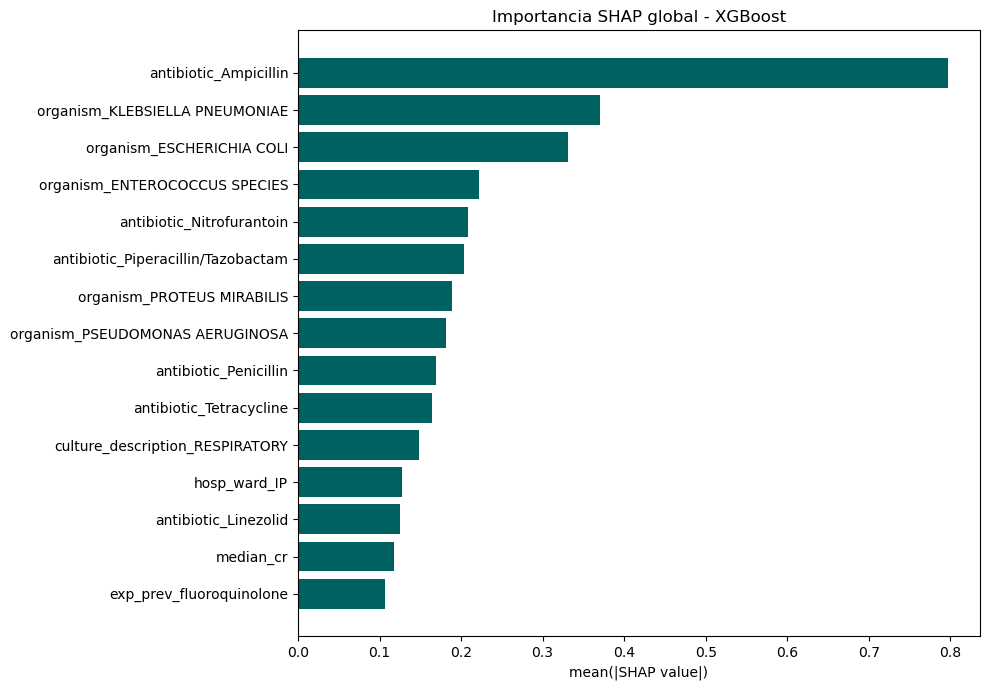

In [8]:
top = df_shap_global.head(15).sort_values('mean_abs_shap')
plt.figure(figsize=(10, 7))
plt.barh(top['variable'], top['mean_abs_shap'], color='#006161')
plt.xlabel('mean(|SHAP value|)')
plt.title('Importancia SHAP global - XGBoost')
plt.tight_layout()
plt.savefig(RUTA_GRAFICAS / 'shap_importancia_global_xgboost.png', dpi=180)
plt.show()

## 9. Guardar artefactos

Estos archivos son los que luego debe cargar el microservicio del modelo.

In [9]:
joblib.dump(modelo_xgb, RUTA_ARTEFACTOS / 'xgboost_shap_exploratorio.joblib')
joblib.dump(le, RUTA_ARTEFACTOS / 'label_encoder_shap_exploratorio.joblib')

metadata = {
    'model_name': 'XGBoost',
    'model_version': 'v2-xgboost-shap',
    'target': TARGET,
    'classes': le.classes_.tolist(),
    'features_count': len(features),
    'xgb_params': xgb_params,
    'shap_method': 'TreeExplainer',
}
(RUTA_ARTEFACTOS / 'xgboost_shap_exploratorio_metadata.json').write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8')

print('Artefactos guardados:')
print(RUTA_ARTEFACTOS / 'xgboost_shap_exploratorio.joblib')
print(RUTA_ARTEFACTOS / 'label_encoder_shap_exploratorio.joblib')
print(RUTA_ARTEFACTOS / 'xgboost_shap_exploratorio_metadata.json')

Artefactos guardados:
D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\06_ARTEFACTOS\xgboost_shap_exploratorio.joblib
D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\06_ARTEFACTOS\label_encoder_shap_exploratorio.joblib
D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\06_ARTEFACTOS\xgboost_shap_exploratorio_metadata.json
